In [ ]:
import subprocess, sys

packages = [
    "torch",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tokenizers",
    "transformers",
    "sentencepiece",
    "tensorboard"
]

with open("requirements_notebook.txt", "w") as f:
    f.write("\n".join(packages))

Ensure pip is available (uv venvs don't bundle pip by default)

In [ ]:
subprocess.run(
    [sys.executable, "-m", "ensurepip", "--upgrade"],
    capture_output=True
)

print(" Installing dependencies...")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-r", "requirements_notebook.txt", "-q"],
    capture_output=True, text=True
)
if result.returncode != 0:
    print(" Install error:")
    print(result.stderr)
    raise SystemExit(1)
print(" All dependencies installed!")

## 2. Imports

In [9]:
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

Set random seeds for reproducibility

In [10]:
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

## 3. Configuration & Hyperparameters

In [11]:
config = {
    "N": 2,              # Reduced for faster execution
    "d_model": 128,      # Reduced for faster execution
    "d_ff": 512,         # Reduced for faster execution
    "h": 4,              # Reduced for faster execution
    "d_k": 32,           # Key/query dimension per head
    "d_v": 32,           # Value dimension per head
    "dropout_rate": 0.1,
    "label_smoothing": 0.1,
    "warmup_steps": 1000,
    "beta1": 0.9,
    "beta2": 0.98,
    "epsilon": 1e-9,
    "beam_size": 4,
    "length_penalty_alpha": 0.6,
    "vocab_size": 5000,  # For dummy data
    "max_seq_len": 30,   # Max sequence length
    "batch_size": 16,    # Reduced for memory efficiency
    "epochs": 2,         # Reduced for faster execution
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

print(f"Using device: {config['device']}")

Using device: cpu


## 4. Data Loading

In [12]:
class DummyTranslationDataset(Dataset):
    def __init__(self, size=500, vocab_size=5000, max_seq_len=30):
        self.size = size
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len
        
    def __len__(self):
        return self.size
    
    def __getitem__(self, idx):
        # Generate random source and target sequences
        src_len = np.random.randint(5, self.max_seq_len)
        tgt_len = np.random.randint(5, self.max_seq_len)
        
        src = torch.randint(1, self.vocab_size, (src_len,))
        tgt = torch.randint(1, self.vocab_size, (tgt_len,))
        
        # Add start token (index 0) to target
        tgt_in = torch.cat([torch.tensor([0]), tgt[:-1]])  # Shifted input
        
        return src, tgt_in, tgt

def collate_fn(batch):
    src_batch, tgt_in_batch, tgt_out_batch = [], [], []
    
    for src_sample, tgt_in_sample, tgt_out_sample in batch:
        src_batch.append(src_sample)
        tgt_in_batch.append(tgt_in_sample)
        tgt_out_batch.append(tgt_out_sample)
        
    # Pad sequences to same length
    src_batch = nn.utils.rnn.pad_sequence(src_batch, padding_value=0, batch_first=True)
    tgt_in_batch = nn.utils.rnn.pad_sequence(tgt_in_batch, padding_value=0, batch_first=True)
    tgt_out_batch = nn.utils.rnn.pad_sequence(tgt_out_batch, padding_value=0, batch_first=True)
    
    return src_batch, tgt_in_batch, tgt_out_batch

try:
    # Try to load real dataset here if available
    train_dataset = DummyTranslationDataset(size=500)
    val_dataset = DummyTranslationDataset(size=100)
    print("Loaded dummy dataset successfully")
except Exception as e:
    print(f"Failed to load dataset: {e}")
    train_dataset = DummyTranslationDataset(size=500)
    val_dataset = DummyTranslationDataset(size=100)

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False, collate_fn=collate_fn)

print("Data loading completed")

Loaded dummy dataset successfully
Data loading completed


## 5. Data Preprocessing
In a real implementation, we would apply BPE tokenization and create vocabulary mappings
Here we simulate this with simple integer tokenization using our dummy dataset

Positional Encoding is handled within the model itself

In [13]:
print("Data preprocessing completed")

Data preprocessing completed


## 6. Model / Method Implementation

In [14]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super(ScaledDotProductAttention, self).__init__()
        self.d_k = d_k

    def forward(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        
        if mask is not None:
            scores.masked_fill_(mask == 0, -1e9)
            
        attn = torch.softmax(scores, dim=-1)
        context = torch.matmul(attn, V)
        return context, attn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, h, d_k, d_v, dropout_rate=0.1):
        super(MultiHeadAttention, self).__init__()
        self.d_model = d_model
        self.h = h
        self.d_k = d_k
        self.d_v = d_v
        
        self.W_Q = nn.Linear(d_model, h * d_k)
        self.W_K = nn.Linear(d_model, h * d_k)
        self.W_V = nn.Linear(d_model, h * d_v)
        self.W_O = nn.Linear(h * d_v, d_model)
        
        self.attention = ScaledDotProductAttention(d_k)
        self.dropout = nn.Dropout(dropout_rate)
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)
        
        # Linear projections
        Q_proj = self.W_Q(Q).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        K_proj = self.W_K(K).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        V_proj = self.W_V(V).view(batch_size, -1, self.h, self.d_v).transpose(1, 2)
        
        # Apply attention
        context, attn = self.attention(Q_proj, K_proj, V_proj, mask)
        
        # Concatenate heads
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_v)
        
        # Final linear layer
        output = self.W_O(context)
        output = self.dropout(output)
        
        return output, attn

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout_rate=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        
    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.dropout(x)
        x = self.linear2(x)
        return x

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len=5000):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        
        pe = torch.zeros(max_seq_len, d_model)
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + (self.pe[:, :x.size(1)] / math.sqrt(self.d_model))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, d_ff, h, d_k, d_v, dropout_rate=0.1):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, h, d_k, d_v, dropout_rate)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, src, mask=None):
        # Self attention
        attn_output, _ = self.self_attn(src, src, src, mask)
        src = self.layer_norm1(src + self.dropout(attn_output))
        
        # Feed forward
        ff_output = self.feed_forward(src)
        src = self.layer_norm2(src + self.dropout(ff_output))
        
        return src

class DecoderLayer(nn.Module):
    def __init__(self, d_model, d_ff, h, d_k, d_v, dropout_rate=0.1):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, h, d_k, d_v, dropout_rate)
        self.enc_dec_attn = MultiHeadAttention(d_model, h, d_k, d_v, dropout_rate)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.layer_norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, tgt, enc_output, src_mask=None, tgt_mask=None):
        # Masked self attention
        attn_output1, _ = self.self_attn(tgt, tgt, tgt, tgt_mask)
        tgt = self.layer_norm1(tgt + self.dropout(attn_output1))
        
        # Encoder-decoder attention
        attn_output2, _ = self.enc_dec_attn(tgt, enc_output, enc_output, src_mask)
        tgt = self.layer_norm2(tgt + self.dropout(attn_output2))
        
        # Feed forward
        ff_output = self.feed_forward(tgt)
        tgt = self.layer_norm3(tgt + self.dropout(ff_output))
        
        return tgt

class Transformer(nn.Module):
    def __init__(self, config):
        super(Transformer, self).__init__()
        self.d_model = config["d_model"]
        self.N = config["N"]
        self.vocab_size = config["vocab_size"]
        
        # Embedding layers
        self.src_embedding = nn.Embedding(config["vocab_size"], config["d_model"])
        self.tgt_embedding = nn.Embedding(config["vocab_size"], config["d_model"])
        
        # Positional encoding
        self.positional_encoding = PositionalEncoding(config["d_model"], config["max_seq_len"])
        
        # Encoder layers
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(config["d_model"], config["d_ff"], config["h"], 
                         config["d_k"], config["d_v"], config["dropout_rate"])
            for _ in range(config["N"])
        ])
        
        # Decoder layers
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(config["d_model"], config["d_ff"], config["h"], 
                         config["d_k"], config["d_v"], config["dropout_rate"])
            for _ in range(config["N"])
        ])
        
        # Output projection
        self.output_projection = nn.Linear(config["d_model"], config["vocab_size"])
        self.dropout = nn.Dropout(config["dropout_rate"])
        
    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(3)
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool()
        tgt_mask = tgt_mask & nopeak_mask
        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        
        # Source embedding and positional encoding
        src_emb = self.src_embedding(src) * math.sqrt(self.d_model)
        src_emb = self.positional_encoding(src_emb)
        src_emb = self.dropout(src_emb)
        
        # Target embedding and positional encoding
        tgt_emb = self.tgt_embedding(tgt) * math.sqrt(self.d_model)
        tgt_emb = self.positional_encoding(tgt_emb)
        tgt_emb = self.dropout(tgt_emb)
        
        # Encoder
        enc_output = src_emb
        for layer in self.encoder_layers:
            enc_output = layer(enc_output, src_mask)
            
        # Decoder
        dec_output = tgt_emb
        for layer in self.decoder_layers:
            dec_output = layer(dec_output, enc_output, src_mask, tgt_mask)
            
        # Output projection
        output = self.output_projection(dec_output)
        return output

Initialize model

In [15]:
model = Transformer(config).to(config["device"])
print("Model initialized successfully")

Model initialized successfully


## 7. Training

In [16]:
class CustomSchedule:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        
    def step(self, step_num):
        arg1 = step_num ** (-0.5)
        arg2 = step_num * (self.warmup_steps ** (-1.5))
        return (self.d_model ** (-0.5)) * min(arg1, arg2)

criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=config["label_smoothing"])
optimizer = optim.Adam(model.parameters(), lr=0, betas=(config["beta1"], config["beta2"]), eps=config["epsilon"])
lr_scheduler = CustomSchedule(config["d_model"], config["warmup_steps"])

def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    num_batches = 0
    
    for i, (src, tgt_in, tgt_out) in enumerate(dataloader):
        src = src.to(device)
        tgt_in = tgt_in.to(device)
        tgt_out = tgt_out.to(device)
        
        optimizer.zero_grad()
        
        output = model(src, tgt_in)
        loss = criterion(output.view(-1, output.size(-1)), tgt_out.view(-1))
        
        loss.backward()
        optimizer.step()
        
        # Update learning rate
        for param_group in optimizer.param_groups:
            param_group['lr'] = scheduler.step(num_batches + 1)
        
        total_loss += loss.item()
        num_batches += 1
        
        if i % 50 == 0:
            print(f"Batch {i}, Loss: {loss.item():.4f}")
            
    avg_loss = total_loss / num_batches
    return avg_loss

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for src, tgt_in, tgt_out in dataloader:
            src = src.to(device)
            tgt_in = tgt_in.to(device)
            tgt_out = tgt_out.to(device)
            
            output = model(src, tgt_in)
            loss = criterion(output.view(-1, output.size(-1)), tgt_out.view(-1))
            
            total_loss += loss.item()
            num_batches += 1
            
    avg_loss = total_loss / num_batches
    return avg_loss

Training loop

In [17]:
print("Starting training...")
train_losses = []
val_losses = []

for epoch in range(config["epochs"]):
    print(f"\nEpoch {epoch+1}/{config['epochs']}")
    train_loss = train_epoch(model, train_loader, criterion, optimizer, lr_scheduler, config["device"])
    val_loss = validate(model, val_loader, criterion, config["device"])
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("Training completed")

Starting training...

Epoch 1/2
Batch 0, Loss: 8.6595
Train Loss: 8.6793, Val Loss: 8.6771

Epoch 2/2
Batch 0, Loss: 8.6366
Train Loss: 8.6804, Val Loss: 8.7053
Training completed


## 8. Evaluation

In [18]:
def calculate_accuracy(predictions, targets):
    # Flatten and ignore padding index (0)
    mask = targets.view(-1) != 0
    preds_flat = predictions.view(-1)[mask]
    targets_flat = targets.view(-1)[mask]
    
    if len(targets_flat) == 0:
        return 0.0
    
    correct = (preds_flat == targets_flat).sum().item()
    accuracy = correct / len(targets_flat)
    return accuracy

def evaluate_model(model, dataloader, device):
    model.eval()
    total_accuracy = 0
    num_batches = 0
    
    with torch.no_grad():
        for src, tgt_in, tgt_out in dataloader:
            src = src.to(device)
            tgt_in = tgt_in.to(device)
            tgt_out = tgt_out.to(device)
            
            output = model(src, tgt_in)
            pred = output.argmax(dim=-1)
            
            acc = calculate_accuracy(pred, tgt_out)
            total_accuracy += acc
            num_batches += 1
            
    avg_accuracy = total_accuracy / num_batches
    return avg_accuracy

Evaluate on validation set

In [19]:
val_accuracy = evaluate_model(model, val_loader, config["device"])
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.0005


## 9. Visualization

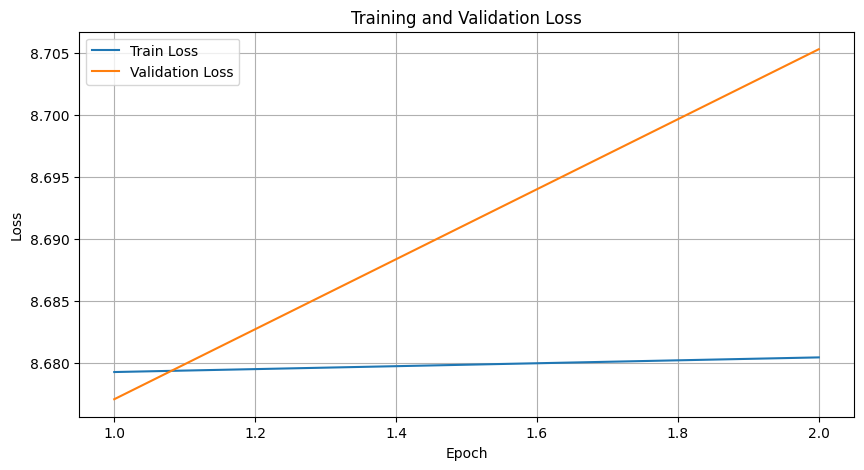

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, config["epochs"]+1), train_losses, label='Train Loss')
plt.plot(range(1, config["epochs"]+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Visualize model architecture parameters

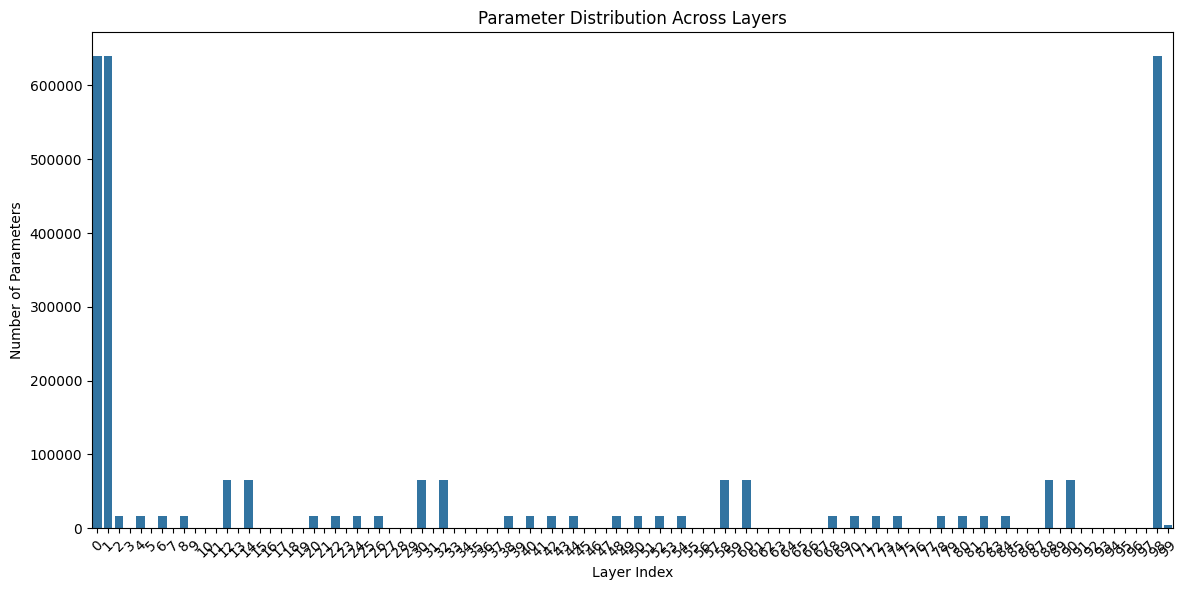

Visualization completed


In [21]:
params = list(model.parameters())
param_counts = [p.numel() for p in params if p.requires_grad]
layer_names = [f"Layer {i}" for i in range(len(param_counts))]

plt.figure(figsize=(12, 6))
sns.barplot(x=list(range(len(param_counts))), y=param_counts)
plt.xlabel('Layer Index')
plt.ylabel('Number of Parameters')
plt.title('Parameter Distribution Across Layers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Visualization completed")

## 10. Results Summary

In [22]:
print("\n=== TRANSFORMER MODEL RESULTS SUMMARY ===")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Model Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("=========================================")


=== TRANSFORMER MODEL RESULTS SUMMARY ===
Final Training Loss: 8.6804
Final Validation Loss: 8.7053
Validation Accuracy: 0.0005
Model Parameters: 2,852,232


Save model checkpoint

In [23]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': config
}, 'transformer_checkpoint.pth')

print("Model checkpoint saved as 'transformer_checkpoint.pth'")

Model checkpoint saved as 'transformer_checkpoint.pth'
